# Human evaluation — Section 1 (PR vs. SRR)

Blind expert preference for **Primary Response (PR; Response A)** vs. **Selected Refined Response (SRR; Response B)** for each of the five primary LLMs.

Loads Section 1 from `data/human_eval_section1_responses.csv` (falls back to the Google Form `.xlsx` if needed), plots evaluator counts per primary LLM, and reports **Gwet's AC1** inter-rater agreement across the three experts.

In [25]:
from __future__ import annotations

from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# Prefer bundled CSV (avoids openpyxl / numpy issues in some Jupyter kernels).
EVAL_CSV = Path("data/human_eval_section1_responses.csv")
EVAL_XLSX = Path(
    "/Users/narenkhatwani/Downloads/LLM Human Evaluation - LLM Roundtable (Responses).xlsx"
)
SHEET_NAME = "Form Responses 1"

PRIMARY_LLMS = [
    "GPT-5.6 Sol",
    "Kimi-K3",
    "Qwen3.7-Max",
    "Gemini-3.1-Pro",
    "Claude-Opus-4.8",
]

SECTION1_PREF_COLS = [
    "1. Which response do you prefer overall?",
    "1. Which response do you prefer overall? 2",
    "1. Which response do you prefer overall? 3",
    "1. Which response do you prefer overall? 4",
    "1. Which response do you prefer overall? 5",
]


def load_eval_responses() -> pd.DataFrame:
    if EVAL_CSV.exists():
        return pd.read_csv(EVAL_CSV)
    if EVAL_XLSX.exists():
        return pd.read_excel(EVAL_XLSX, sheet_name=SHEET_NAME)
    raise FileNotFoundError(
        f"Neither {EVAL_CSV} nor {EVAL_XLSX} found. "
        "Export Section 1 from the Google Form to data/human_eval_section1_responses.csv"
    )


raw = load_eval_responses()
source = EVAL_CSV if EVAL_CSV.exists() else EVAL_XLSX
print(f"Loaded {len(raw)} evaluator responses from {source}")

Loaded 3 evaluator responses from data/human_eval_section1_responses.csv


## Section 1 preferences (subjects × raters)

In [26]:
def normalize_choice(value: object) -> str:
  text = str(value).strip()
  if text.endswith("A"):
    return "A"
  if text.endswith("B"):
    return "B"
  raise ValueError(f"Unexpected preference value: {value!r}")


ratings = raw[SECTION1_PREF_COLS].copy()
ratings.columns = PRIMARY_LLMS
ratings = ratings.map(normalize_choice)

# subjects (PR–SRR pairs) × raters (evaluators)
subject_rater = ratings.T
subject_rater.columns = [f"Evaluator {i + 1}" for i in range(len(raw))]

display(subject_rater)

counts = pd.DataFrame(
    {
        "PR (Response A)": [(subject_rater.loc[m] == "A").sum() for m in PRIMARY_LLMS],
        "SRR (Response B)": [(subject_rater.loc[m] == "B").sum() for m in PRIMARY_LLMS],
    },
    index=PRIMARY_LLMS,
)
counts["Total evaluators"] = counts.sum(axis=1)
display(counts)

,Evaluator 1,Evaluator 2,Evaluator 3
GPT-5.6 Sol,B,B,B
Kimi-K3,B,B,A
Qwen3.7-Max,B,B,B
Gemini-3.1-Pro,B,B,A
Claude-Opus-4.8,B,B,B


,PR (Response A),SRR (Response B),Total evaluators
GPT-5.6 Sol,0,3,3
Kimi-K3,1,2,3
Qwen3.7-Max,0,3,3
Gemini-3.1-Pro,1,2,3
Claude-Opus-4.8,0,3,3


## Bar chart — evaluator preference by primary LLM

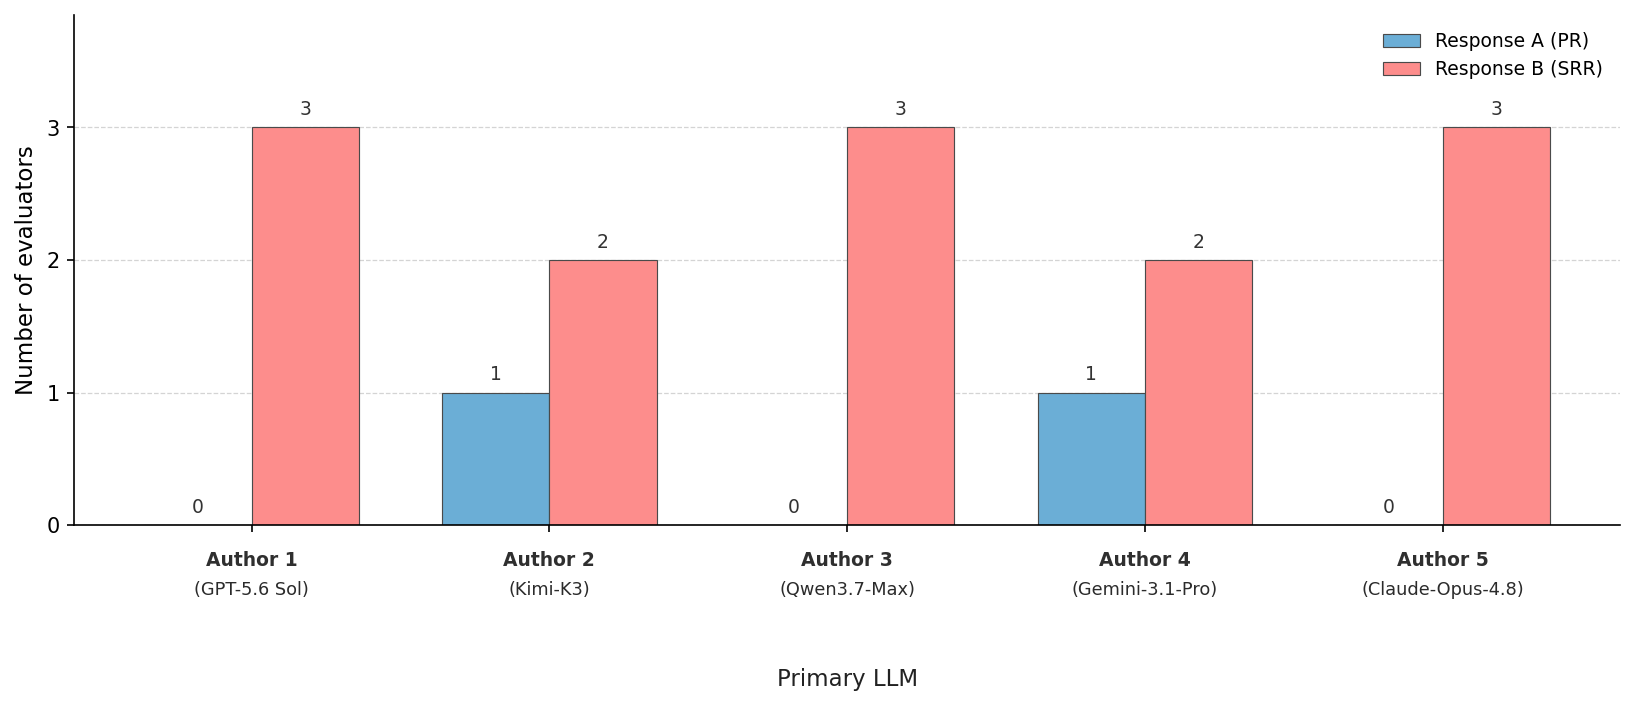

In [27]:
response_a = counts["PR (Response A)"].tolist()
response_b = counts["SRR (Response B)"].tolist()

# Pastel palette — swap these if you want a different look:
#   A (current): sky blue + coral
#   B: #66C2A5 + #FC8D62  (teal + orange)
#   C: #A6CEE3 + #B2DF8A  (blue + green)
COLOR_PR = "#6BAED6"
COLOR_SRR = "#FD8D8C"
EDGE = "#4A4A4A"
EDGE_LW = 0.55

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

x = np.arange(len(PRIMARY_LLMS))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 4.8), dpi=150)

bars_a = ax.bar(
    x - width / 2,
    response_a,
    width,
    label="Response A (PR)",
    color=COLOR_PR,
    edgecolor=EDGE,
    linewidth=EDGE_LW,
)
bars_b = ax.bar(
    x + width / 2,
    response_b,
    width,
    label="Response B (SRR)",
    color=COLOR_SRR,
    edgecolor=EDGE,
    linewidth=EDGE_LW,
)

ax.set_ylabel("Number of evaluators")
ax.set_xticks(x)
ax.set_xticklabels([])

# Top → bottom: Author label, (model name), then axis title below all groups
for i, name in enumerate(PRIMARY_LLMS):
    ax.text(
        i,
        -0.05,
        f"Author {i + 1}",
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=9,
        fontweight="semibold",
        color="#2F2F2F",
        clip_on=False,
    )
    ax.text(
        i,
        -0.11,
        f"({name})",
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=8.5,
        color="#2B2B2B",
        clip_on=False,
    )

ax.text(
    (len(PRIMARY_LLMS) - 1) / 2,
    -0.28,
    "Primary LLM",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="top",
    fontsize=11,
    color="#222222",
    clip_on=False,
)
ax.set_xlabel("")
ax.set_ylim(0, max(max(response_a), max(response_b)) + 0.85)
ax.set_yticks(range(len(raw) + 1))
ax.yaxis.grid(True, linestyle="--", linewidth=0.6, color="#D0D0D0", alpha=0.9)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="upper right")

ax.bar_label(bars_a, padding=4, fontsize=9, color="#333333")
ax.bar_label(bars_b, padding=4, fontsize=9, color="#333333")

plt.tight_layout()
plt.subplots_adjust(bottom=0.26)
plt.show()

## Inter-rater agreement (Gwet's AC1)

Three evaluators × five PR–SRR pairs; binary categories **Response A** vs. **Response B**.

In [28]:
def gwet_ac1(subject_rater_df: pd.DataFrame) -> dict[str, float]:
    """Gwet's AC1 for nominal categories (subjects × raters). No scipy dependency."""
    categories = sorted(subject_rater_df.stack().unique().tolist())
    q = len(categories)
    ratings = subject_rater_df.copy()
    n, _r = ratings.shape

    agree_mat = np.zeros((n, q), dtype=float)
    for k, cat in enumerate(categories):
        agree_mat[:, k] = (ratings.values == cat).sum(axis=1)

    ri_vec = agree_mat.sum(axis=1)
    sum_q = (agree_mat * (agree_mat - 1)).sum(axis=1)
    n2more = int((ri_vec >= 2).sum())
    pa = float(
        (sum_q[ri_vec >= 2] / (ri_vec * (ri_vec - 1))[ri_vec >= 2]).sum() / n2more
    )

    pi_vec = (
        np.repeat(1 / n, n).reshape(n, 1)
        * (agree_mat / np.repeat(ri_vec, q).reshape(n, q))
    ).T.sum(axis=1)
    pe = float(q * np.sum(pi_vec * (1 - pi_vec)) / (q * (q - 1)))
    ac1 = float((pa - pe) / (1 - pe))
    return {"ac1": ac1, "pa": pa, "pe": pe}


gwet = gwet_ac1(subject_rater)

pairwise_agree = []
for _, row in subject_rater.iterrows():
    vals = row.tolist()
    agree = sum(int(vals[i] == vals[j]) for i, j in combinations(range(len(vals)), 2))
    pairwise_agree.append(agree / len(list(combinations(range(len(vals)), 2))))
observed_pairwise = float(np.mean(pairwise_agree))

agreement_summary = pd.DataFrame(
    [
        {"metric": "Observed pairwise agreement", "value": observed_pairwise},
        {"metric": "Gwet's AC1", "value": gwet["ac1"]},
        {"metric": "Gwet chance agreement (Pe)", "value": gwet["pe"]},
    ]
)
display(agreement_summary.round(3))

,metric,value
0,Observed pairwise agreement,0.733
1,Gwet's AC1,0.653
2,Gwet chance agreement (Pe),0.231


## Paper-ready summary

In [29]:
def preference_sentence(model: str, n_b: int, n_total: int) -> str:
    if n_b == n_total:
        return f"all {n_total} evaluators preferred the SRR"
    if n_b > n_total / 2:
        return f"{n_b} of {n_total} evaluators preferred the SRR"
    n_a = n_total - n_b
    return f"{n_a} of {n_total} evaluators preferred the PR"


per_pair = [
    f"- **{model}:** {preference_sentence(model, int(row['SRR (Response B)']), int(row['Total evaluators']))}"
    for model, row in counts.iterrows()
]

unanimous = int((counts["SRR (Response B)"] == counts["Total evaluators"]).sum())
majority_srr = int((counts["SRR (Response B)"] > counts["Total evaluators"] / 2).sum())
total_b = int(counts["SRR (Response B)"].sum())
total_choices = int(counts["Total evaluators"].sum())
ac1 = gwet["ac1"]

summary_md = f"""**Results (Section 1 — PR vs. SRR)**

The Selected Refined Response (SRR; Response B) was preferred by the majority of evaluators for all five Primary Responses ({majority_srr}/5 pairs). {unanimous} of 5 pairs received unanimous SRR preference (3–0 counts), and the remaining {5 - unanimous} pairs received majority SRR preference (2–1 counts). In total, {total_b}/{total_choices} individual evaluator choices favored the SRR.

**Per primary LLM:**
{chr(10).join(per_pair)}

**Inter-rater agreement:** Observed pairwise agreement = {observed_pairwise:.3f}; Gwet's AC1 = {ac1:.3f} (report as **{ac1:.2f}** in prose unless using three decimals throughout).
"""

display(Markdown(summary_md))

**Results (Section 1 — PR vs. SRR)**

The Selected Refined Response (SRR; Response B) was preferred by the majority of evaluators for all five Primary Responses (5/5 pairs). 3 of 5 pairs received unanimous SRR preference (3–0 counts), and the remaining 2 pairs received majority SRR preference (2–1 counts). In total, 13/15 individual evaluator choices favored the SRR.

**Per primary LLM:**
- **GPT-5.6 Sol:** all 3 evaluators preferred the SRR
- **Kimi-K3:** 2 of 3 evaluators preferred the SRR
- **Qwen3.7-Max:** all 3 evaluators preferred the SRR
- **Gemini-3.1-Pro:** 2 of 3 evaluators preferred the SRR
- **Claude-Opus-4.8:** all 3 evaluators preferred the SRR

**Inter-rater agreement:** Observed pairwise agreement = 0.733; Gwet's AC1 = 0.653 (report as **0.65** in prose unless using three decimals throughout).


## Export (optional)

In [30]:
SAVE_OUTPUTS = True
OUTPUT_DIR = Path("outputs/human_eval")

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    subject_rater.to_csv(OUTPUT_DIR / "section1_preferences.csv")
    counts.to_csv(OUTPUT_DIR / "section1_counts.csv")
    agreement_summary.round(4).to_csv(OUTPUT_DIR / "section1_agreement.csv", index=False)
    fig.savefig(OUTPUT_DIR / "section1_preference_bar.png", dpi=200, bbox_inches="tight")
    (OUTPUT_DIR / "section1_summary.md").write_text(summary_md, encoding="utf-8")
    print("Wrote outputs to", OUTPUT_DIR.resolve())

Wrote outputs to /Users/narenkhatwani/GitHub/llm-roundtable/outputs/human_eval


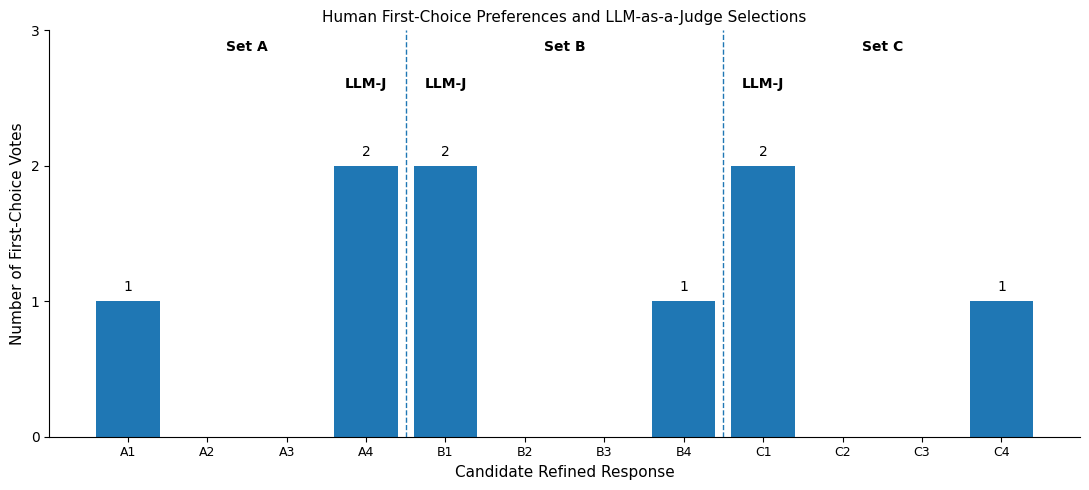

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# First-choice votes from the three evaluators
labels = [
    "A1", "A2", "A3", "A4",
    "B1", "B2", "B3", "B4",
    "C1", "C2", "C3", "C4"
]

votes = [1, 0, 0, 2,
         2, 0, 0, 1,
         2, 0, 0, 1]

# Responses selected by the LLM-as-a-Judge
judge_selected = {"A4", "B1", "C1"}

x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(x, votes)

# Annotate each bar
for bar, label, vote in zip(bars, labels, votes):
    if vote > 0:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            vote + 0.05,
            str(vote),
            ha="center",
            va="bottom"
        )

    # Mark judge-selected responses
    if label in judge_selected:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            2.55,
            "LLM-J",
            ha="center",
            va="bottom",
            fontweight="bold"
        )

# Separate the three response sets
ax.axvline(3.5, linestyle="--", linewidth=1)
ax.axvline(7.5, linestyle="--", linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylabel("Number of First-Choice Votes")
ax.set_xlabel("Candidate Refined Response")
ax.set_title("Human First-Choice Preferences and LLM-as-a-Judge Selections")

ax.set_ylim(0, 3)
ax.set_yticks([0, 1, 2, 3])

# Group labels
ax.text(1.5, 2.85, "Set A", ha="center", fontweight="bold")
ax.text(5.5, 2.85, "Set B", ha="center", fontweight="bold")
ax.text(9.5, 2.85, "Set C", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()